# Классификация текста 
## Ссылки

https://www.youtube.com/watch?v=AwdawjHJstU - Классификация текста | Обработка естественного языка</br>
https://www.youtube.com/watch?v=55Iyei3bkKk&list=PLtPJ9lKvJ4ohZpMV9Ml-DPtMSXPFNl6Sz</br>

https://www.youtube.com/watch?v=-2O0ODmnw1o - NLP cookbook: анализируем тексты на Python с минимальными знаниями о машинном обучении

# 0. Импорты

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords
import string
import re
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


# 1. Загрузка датасета

In [2]:
df = pd.read_json("data/data.txt", lines=True)
df

,text,tags,schema_name,table_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876


In [3]:
final_df = df.copy()

In [4]:
final_df['full_table_name'] = final_df['schema_name'] + '.' + final_df['table_name']
final_df['class_name'] =  final_df['tags'].apply(lambda x: '/'.join(x))
final_df['class_id'] = pd.factorize(final_df['class_name'])[0]
final_df

,text,tags,schema_name,table_name,full_table_name,class_name,class_id
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,МКА. Геоданные/440 Особо охраняемые природные ...,0
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,МКА. Геоданные/440 Особо охраняемые природные ...,1
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,МКА. Геоданные/440 Особо охраняемые природные ...,1
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,МКА. Геоданные/440 Особо охраняемые природные ...,1
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,МКА. Геоданные/440 Особо охраняемые природные ...,1
...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,МКА. Геоданные/440 Особо охраняемые природные ...,20
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,МКА. Геоданные/440 Особо охраняемые природные ...,20
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,МКА. Геоданные/440 Особо охраняемые природные ...,20
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,МКА. Геоданные/440 Особо охраняемые природные ...,20


# Анализ датасета
## Распределение данных по классам

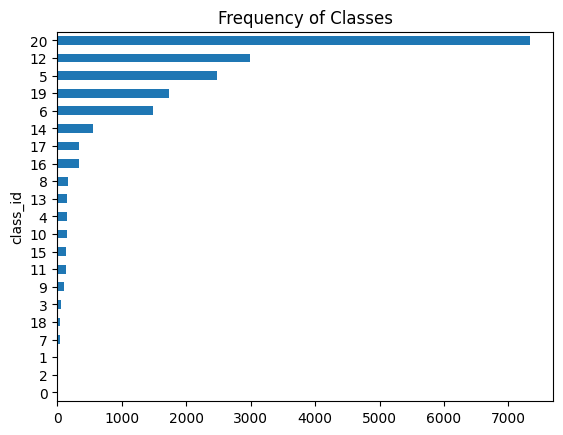

In [9]:
# узнаем кол-во примеров в каждом классе
final_df["class_id"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [8]:
final_df["class_id"].value_counts(ascending=True)

class_id
0        1
2        1
1        6
7       46
18      50
3       64
9      108
11     133
15     144
10     146
4      148
13     156
8      164
16     342
17     343
14     558
6     1483
19    1727
5     2485
12    2992
20    7327
Name: count, dtype: int64

## Распределение кол-ва токенов в классах

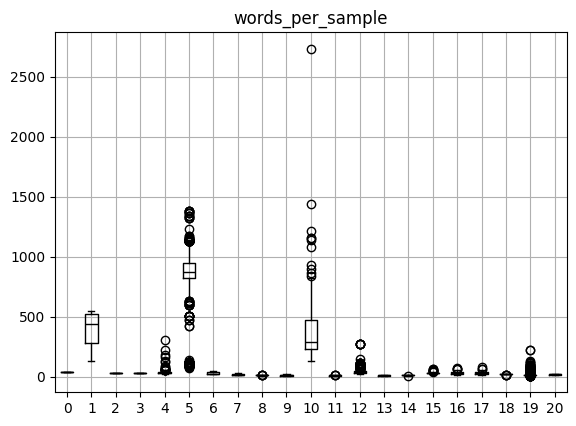

In [15]:
# кол-во слов в каждом классе
final_df["words_per_sample"] = final_df["text"].str.split().apply(len)
final_df.boxplot("words_per_sample", by="class_id", grid=True,
showfliers=True, color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()


# Получение эмбедингов

Итоговые рекомендации:
Прекратите удалять стоп-words и, возможно, прекратите приводить к нижнему регистру. Просто проведите базовую очистку: удалите лишние пробелы, спецсимволы, HTML-теги, если они есть, и т.д.

Никакой дополнительной токенизации не нужно. Просто передавайте строку в model.encode(). Доверяйте встроенному пайплайну SentenceTransformer. Он отлично спроектирован и сам выполнит всю необходимую низкоуровневую работу. Ваша задача — подать на вход качественный, связный текст

In [ ]:
# Загрузка модели Sentence-BERT (выбираем multilingual версию)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

In [ ]:
# Загрузка стоп-слов (один раз при старте)
# nltk.download('stopwords')
# stop_words = set(stopwords.words('russian')) # Загрузка стоп-слов (один раз при старте)

In [ ]:
# Функция для очистки текста
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Удаление URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    # Удаление цифр и специальных символов
    text = re.sub(r'\d+', ' ', text)
    # Удаление пунктуации
    # text = text.translate(str.maketrans('', '', string.punctuation))
    translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    text = text.translate(translator)
    # Приведение к нижнему регистру (не всегда обязательно, возможно ухудшит качество)
    text = text.lower()
    # Удаление стоп-слов (не всегда  обязательно, возможно ухудшит качество)
    # stop_words = set(stopwords.words('russian'))
    words = text.split()
    # words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)